In [1]:
import jieba
from collections import defaultdict
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import re
import math
import matplotlib
from sklearn.metrics  import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [2]:
df = pd.read_csv('C:waimai_10k.csv', encoding='utf-8', encoding_errors='ignore')
df

,label,review
0,1,很快，好吃，味道足，量大
1,1,没有送水没有送水没有送水
2,1,非常快，态度好。
3,1,方便，快捷，味道可口，快递给力
4,1,菜味道很棒！送餐很及时！
...,...,...
11982,0,以前几乎天天吃，现在调料什么都不放，
11983,0,昨天订凉皮两份，什么调料都没有放，就放了点麻油，特别难吃，丢了一份，再也不想吃了
11984,0,"凉皮太辣,吃不下都"
11985,0,本来迟到了还自己点！！！


In [3]:
labelCount = df.groupby('label')['label'].count()
labelCount

label
0    7987
1    4000
Name: label, dtype: int64

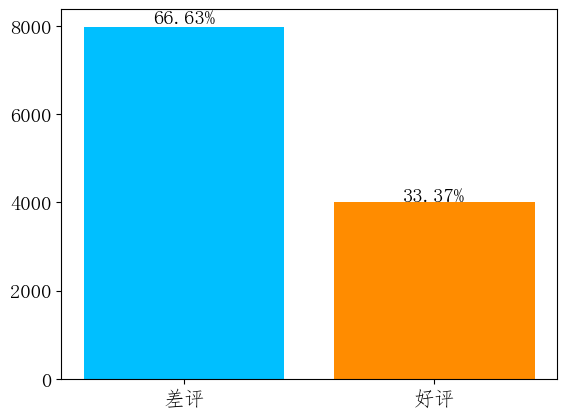

In [32]:
matplotlib.rc("font",family='FangSong',size='15')

xticks = [ '差评','好评']
percent = labelCount/labelCount.sum()
plt.bar(labelCount.index, labelCount.values, color=['#00BFFF','#FF8C00'])
plt.xticks(labelCount.index, xticks)
for i, p in enumerate(percent):
    plt.text(i, labelCount[i]*1.01, '{:.2%}'.format(p), horizontalalignment='center')
plt.savefig('c:/commentDistribution.jpg')

In [5]:
#加载停用词
with open('./stopwords-master/hit_stopwords.txt', 'r', encoding='UTF-8') as stop_path:
    stop_words = set(stop_path.read().split())

In [6]:
def wordlist(text):
    if isinstance(text, str):
        text = re.sub(r'[^\w\s]', '', text)
        words = jieba.cut(text)
        return ' '.join(w for w in words if w not in stop_words or len(w) > 1)
    else:
        return ''

In [7]:
df['review'] = df['review'].apply(wordlist)
df

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\ADMINI~1\AppData\Local\Temp\jieba.cache
Loading model cost 0.450 seconds.
Prefix dict has been built successfully.


,label,review
0,1,很快 好吃 味道 足量 大
1,1,没有 送水 没有 送水 没有 送水
2,1,非常 快 态度 好
3,1,方便快捷 味道 可口 快 递给 力
4,1,菜 味道 很棒 送餐 很 及时
...,...,...
11982,0,以前 几乎 天天 吃 现在 调料 什么 都 不放
11983,0,昨天 订 凉皮 两份 什么 调料 都 没有 放 放 点 麻油 特别 难吃 丢 一份 再也 不想 吃
11984,0,凉皮 太辣 吃不下 都
11985,0,本来 迟到 还 自己 点


## 划分训练集和测试集

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['label'], test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9589,), (2398,), (9589,), (2398,))

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [11]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [12]:
print(f"特征数量: {len(vectorizer.get_feature_names_out())}")

特征数量: 9023


In [13]:
# 查看最常见的特征
feature_names = vectorizer.get_feature_names_out() 
top_n = 20
top_features = np.argsort(np.asarray(X_train_vec.sum(axis=0)).ravel())[::-1][:top_n] 
print("显著特征:")
print([feature_names[i] for i in top_features])

显著特征:
['好吃', '味道', '不错', '送餐', '小时', '速度', '太慢', '没有', '很快', '一般', '就是', '送到', '有点', '难吃', '非常', '时间', '一个', '外卖', '特别', '送来']


In [14]:
X_train_vec.toarray().shape, X_test_vec.toarray().shape

((9589, 9023), (2398, 9023))

## 结果可视化

In [15]:
from wordcloud import WordCloud
from matplotlib.font_manager import FontProperties

In [16]:
# 模型训练(逻辑回归方法)
model = LogisticRegression()
model.fit(X_train_vec, y_train)
# 模型评估
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")
print(classification_report(y_test, y_pred))

模型准确率: 0.8632193494578816
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1594
           1       0.84      0.73      0.78       804

    accuracy                           0.86      2398
   macro avg       0.86      0.83      0.84      2398
weighted avg       0.86      0.86      0.86      2398



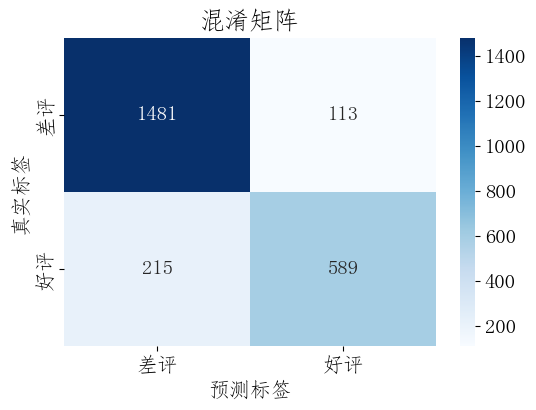

In [17]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['差评', '好评'], yticklabels=['差评', '好评'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵')
plt.show()

## 尝试不同分类器

### 朴素贝叶斯分类器

In [38]:
# 模型训练(朴素贝叶斯方法)
from sklearn.naive_bayes import MultinomialNB
modelBYS = MultinomialNB()
modelBYS.fit(X_train_vec, y_train)
# 模型评估
y_pred = modelBYS.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")
print(classification_report(y_test, y_pred))

模型准确率: 0.854045037531276
              precision    recall  f1-score   support

           0       0.84      0.96      0.90      1594
           1       0.90      0.64      0.75       804

    accuracy                           0.85      2398
   macro avg       0.87      0.80      0.82      2398
weighted avg       0.86      0.85      0.85      2398



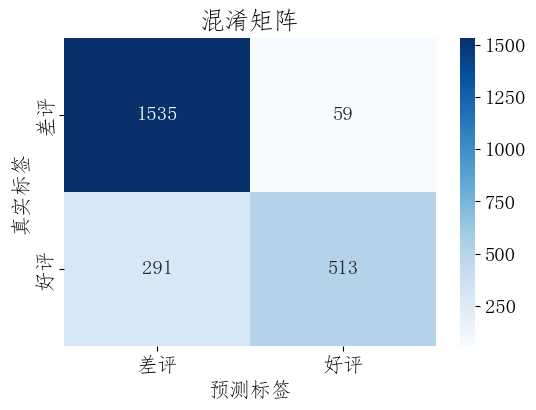

In [19]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['差评', '好评'], yticklabels=['差评', '好评'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵')
plt.show()

### 支持向量机

In [39]:
# 模型训练(支持向量机方法)
from sklearn.svm import SVC
svm = SVC(kernel='linear',probability=True)
svm.fit(X_train_vec, y_train)
# 模型评估
y_pred = svm.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")
print(classification_report(y_test, y_pred))

模型准确率: 0.8732276897414513
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1594
           1       0.82      0.79      0.81       804

    accuracy                           0.87      2398
   macro avg       0.86      0.85      0.86      2398
weighted avg       0.87      0.87      0.87      2398



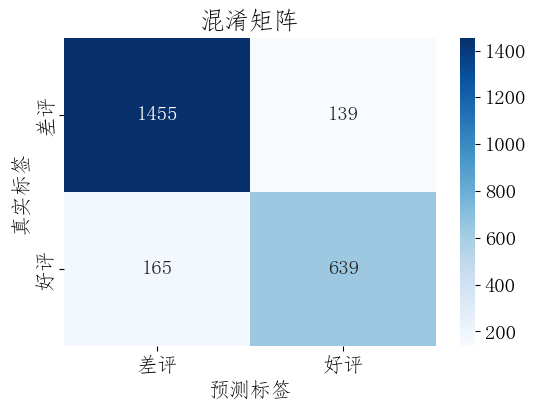

In [21]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['差评', '好评'], yticklabels=['差评', '好评'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵')
plt.show()

In [48]:
#支持向量机（增加差评样本权重）
from sklearn.svm import SVC
svm = SVC(kernel='linear',probability=True,class_weight={0:1.49, 1:1})
svm.fit(X_train_vec, y_train)
# 模型评估
y_pred = svm.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")
print(classification_report(y_test, y_pred))

模型准确率: 0.872393661384487
              precision    recall  f1-score   support

           0       0.88      0.93      0.91      1594
           1       0.84      0.76      0.80       804

    accuracy                           0.87      2398
   macro avg       0.86      0.84      0.85      2398
weighted avg       0.87      0.87      0.87      2398



### 随机森林

In [49]:
# 模型训练(随机森林方法)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_vec, y_train)
# 模型评估
y_pred = rf.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"模型准确率: {accuracy}")
print(classification_report(y_test, y_pred))

模型准确率: 0.8465387823185988
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      1594
           1       0.77      0.78      0.77       804

    accuracy                           0.85      2398
   macro avg       0.83      0.83      0.83      2398
weighted avg       0.85      0.85      0.85      2398



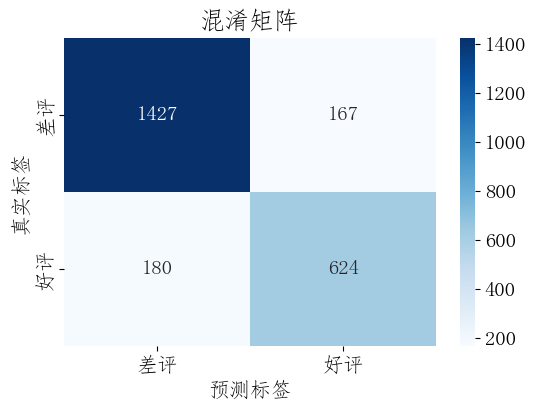

In [23]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['差评', '好评'], yticklabels=['差评', '好评'])
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵')
plt.show()

## 生成关键词云

In [24]:
positive_comments = df[df['label'] == 1]['review']
negative_comments = df[df['label'] == 0]['review']

font_path = 'C:/Windows/Fonts/simhei.ttf'
font_prop = FontProperties(fname=font_path)

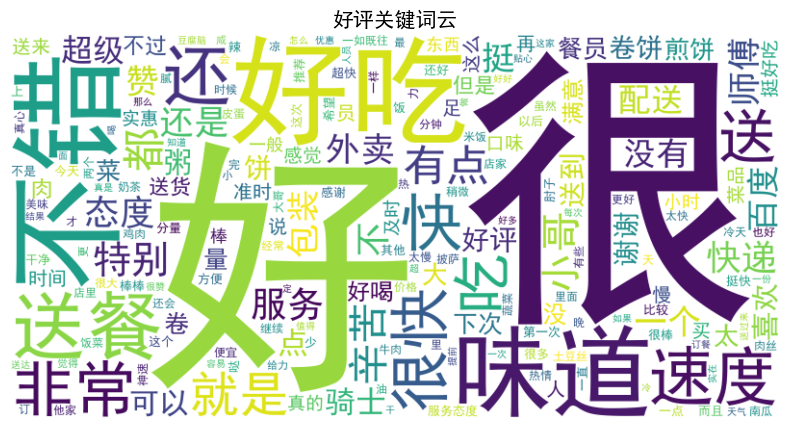

In [25]:
# 生成正面评论关键词云
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False, 
                      font_path=font_path).generate(' '.join(positive_comments))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('好评关键词云', fontproperties='SimHei')
plt.show()

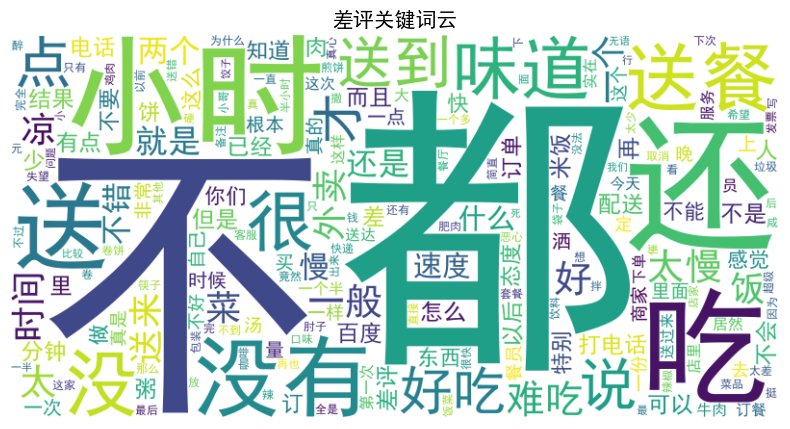

In [26]:
# 生成负面评论关键词云
wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False,
                      font_path=font_path).generate(' '.join(negative_comments))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('差评关键词云',fontproperties='SimHei')
plt.show()

## 模型打包

In [52]:
# 创建完整的文本分类管道
from sklearn.pipeline import Pipeline
text_SVC = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('SVC', svm)
])

In [53]:
# 在整个训练集上重新训练
text_SVC.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('SVC',
                 SVC(class_weight={0: 1.49, 1: 1}, kernel='linear',
                     probability=True))])

In [54]:
# 评估管道
y_pred = text_SVC.predict(X_test) 
print("管道模型准确率:", accuracy_score(y_test, y_pred))

管道模型准确率: 0.872393661384487


In [56]:
import joblib
joblib.dump(text_SVC,  'SVC.pkl') 

['SVC.pkl']

In [62]:
# 测试加载模型
loaded_model = joblib.load('SVC.pkl') 
test_pred = loaded_model.predict(["老板人太实在了，给的份量非常足，味道也是大众口味，性价比超高，以后就是我家的后厨了。包装真的十分用心了，口感质量服务一如既往的好，品质绝对好"])
print(test_pred)

[0]


## 接受输入并判断

In [68]:
def func(text):
    text = wordlist(text)
    prediction = text_SVC.predict([text])
    proba = text_SVC.predict_proba([text])
    if prediction[0] == 1:
        sentiment = '好评'
    else:
        sentiment = '差评'
    confidence = proba[0][prediction[0]]
    
    #print(f"评论: {text}")
    print(f"预测结果: {sentiment} (置信度: {confidence:.2f})")
    print(f"概率分布 - 差评: {proba[0][0]:.2f}, 好评: {proba[0][1]:.2f}")
    return prediction[0], proba

In [69]:
test_review = input("输入评论:")
put = func(test_review)
put

输入评论: 老板人太实在了，给的份量非常足，味道也是大众口味，性价比超高，以后就是我家的后厨了。包装真的十分用心了，口感质量服务一如既往的好，品质绝对好


预测结果: 好评 (置信度: 0.97)
概率分布 - 差评: 0.03, 好评: 0.97


(1, array([[0.03395576, 0.96604424]]))